In [1]:

import json
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from matplotlib import pyplot as plt

import jiwer # for calculating CER

## Load training and validation data

In [2]:
train_csv_path = Path("train.csv") # Adjust path to point to the correct location
val_csv_path = Path("val_predictions_sample.csv")

class ImageDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data.iloc[idx]['image_path']
        label = self.data.iloc[idx]['label']
        img_path = Path("") / img_path # Adjust path to point to the correct location
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

### Plot sample images

In [3]:
train_ds = ImageDataset(train_csv_path, transform=transforms.Compose([
    transforms.Resize((64, 224)),
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
]))
val_ds = ImageDataset(val_csv_path, transform=transforms.Compose([
    transforms.Resize((64, 224)),
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.485, 0.456, 0.406],   std=[0.229, 0.224, 0.225]),
]))


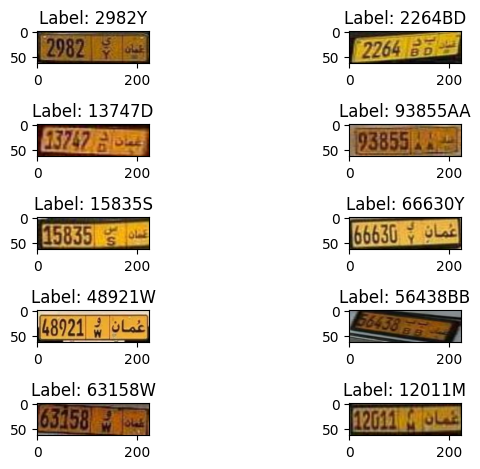

In [4]:
i = 0
figure, ax = plt.subplots(5,2)
for img, label in train_ds:
    ax[i//2, i%2].imshow(img.permute(1, 2, 0)) # note PIL image has shape (C, H, W) but (H, W, C) is needed for plt.imshow
    ax[i//2, i%2].set_title(f"Label: {label}")
    
    i += 1
    if i >= 10:
        break
plt.tight_layout()
plt.show()

## Build label vocabulary (y targets encoding)

In [5]:
def build_vocab(labels):
    chars = sorted({c for s in labels for c in str(s)})
    vocab = {c: i + 1 for i, c in enumerate(chars)}  # 0 is PAD
    inv_vocab = {i: c for c, i in vocab.items()}
    return vocab, inv_vocab

train_df = pd.read_csv(train_csv_path)
vocab, inv_vocab = build_vocab(train_df["label"].tolist()) # get all unique characters from the labels and build a vocab
max_len = int(train_df["label"].astype(str).map(len).max())
num_classes = len(vocab) + 1

In [6]:
vocab,inv_vocab, max_len, num_classes

({'0': 1,
  '1': 2,
  '2': 3,
  '3': 4,
  '4': 5,
  '5': 6,
  '6': 7,
  '7': 8,
  '8': 9,
  '9': 10,
  'A': 11,
  'B': 12,
  'D': 13,
  'F': 14,
  'H': 15,
  'K': 16,
  'L': 17,
  'M': 18,
  'R': 19,
  'S': 20,
  'T': 21,
  'W': 22,
  'Y': 23},
 {1: '0',
  2: '1',
  3: '2',
  4: '3',
  5: '4',
  6: '5',
  7: '6',
  8: '7',
  9: '8',
  10: '9',
  11: 'A',
  12: 'B',
  13: 'D',
  14: 'F',
  15: 'H',
  16: 'K',
  17: 'L',
  18: 'M',
  19: 'R',
  20: 'S',
  21: 'T',
  22: 'W',
  23: 'Y'},
 7,
 24)

## Define the pytorch dataset and dataloaders 


In [7]:
class PlateDataset(Dataset):
    # This dataset class is designed to work with a DataFrame that contains image paths and corresponding labels.
    def __init__(self, data_csv_path, vocab, max_len, transform, root_dir=None):
        self.df = pd.read_csv(data_csv_path)
        self.vocab = vocab
        self.max_len = max_len
        self.transform = transform
        self.root_dir = Path(root_dir) if root_dir else None

    def __len__(self):
        return len(self.df)

    def _resolve_path(self, path):
        p = Path(path)
        if self.root_dir:
            p = self.root_dir / p
        return p

    # The __getitem__ method retrieves an image and its corresponding label from the DataFrame based on the provided index (idx). 
    # It processes the image and converts the label into a tensor format suitable for training a model.
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_rel_path = str(row["image_path"])
        img_path = Path("") / image_rel_path # Adjust path to point to the correct location
        image_path = self._resolve_path(img_path)
        label = str(row["label"])

        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        token_ids = [self.vocab[c] for c in label if c in self.vocab]  # skip OOV chars
        token_ids = token_ids[: self.max_len]
        token_ids = token_ids + [0] * (self.max_len - len(token_ids))
        target = torch.tensor(token_ids, dtype=torch.long)
        return image, target, label, image_rel_path


In [8]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── TRAINING transforms: augmentation + normalization ──
train_transform = transforms.Compose([
    transforms.Resize((64, 200)),
    # Slight tilt / zoom common on real plate photos
    transforms.RandomAffine(degrees=5, translate=(0.02, 0.05), scale=(0.9, 1.1)),
    # Simulate distance / camera angle
    transforms.RandomPerspective(distortion_scale=0.15, p=0.4),
    # Lighting / colour variation
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── VALIDATION transforms: only resize + normalise (no augmentation) ──
val_transform = transforms.Compose([
    transforms.Resize((64, 200)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = PlateDataset(train_csv_path, vocab, max_len,
                        transform=train_transform, root_dir="")
val_ds   = PlateDataset(val_csv_path,   vocab, max_len,
                        transform=val_transform,   root_dir="")

train_ds[0]

(tensor([[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          ...,
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],
 
         [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          ...,
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],
 
         [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
          [-1.8044, -1.8044,

### Define dataloaders and collate function

In [9]:
def collate_fn(batch):
    images, targets, labels, paths = zip(*batch) # you might want to learn about this syntax of using * before variable, 
                                                # it's a neat Python trick for transposing a list of tuples into separate lists
    return torch.stack(images), torch.stack(targets), labels, paths

train_loader = DataLoader(
        train_ds,
        batch_size=16, # how many samples per batch to load
        shuffle=True,
        num_workers=0, # how many subprocesses to use for data loading. 0 means the data will be loaded in the main process. If you have a multi-core CPU or GPU, you can set this to a positive integer to speed up data loading.
        collate_fn=collate_fn,
    )
val_loader = DataLoader(
        val_ds,
        batch_size=16,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    )

for images, targets, labels, paths in train_loader:
    print("Batch of images shape:", images.shape)  # should be (batch_size, 3, 64, 224)
    print("Batch of targets shape:", targets.shape)  # should be (batch_size, max_len)
    print("Batch of labels:", labels)  # list of original label strings
    print("Batch of paths:", paths)  # list of image relative paths
    break

Batch of images shape: torch.Size([16, 3, 64, 200])
Batch of targets shape: torch.Size([16, 7])
Batch of labels: ('9106AD', '10258W', '44416B', '12692S', '657TA', '59002BB', '4580HH', '87693AA', '49648BB', '60724BB', '94931H', '58972BB', '83402H', '67901B', '66517W', '8325MM')
Batch of paths: ('train/9106AD.jpg', 'train/10258W.jpg', 'train/44416B.jpg', 'train/12692S.jpg', 'train/657TA.jpg', 'train/59002BB.jpg', 'train/4580HH.jpg', 'train/87693AA_01.jpg', 'train/49648BB.jpg', 'train/60724BB_01.jpg', 'train/94931H.jpg', 'train/58972BB.jpg', 'train/83402H_01.jpg', 'train/67901B.jpg', 'train/66517W.jpg', 'train/8325MM.jpg')


## Define the pretrained model using pytorch nn.Module class

In [10]:
class Pretrained(nn.Module):
    def __init__(self, num_classes, max_len, backbone="resnet18"):
        super().__init__()
        self.max_len = max_len

        try:
            weights = models.get_model_weights(backbone).DEFAULT
        except Exception:
            weights = None

        resnet = models.get_model(backbone, weights=weights)
        self.encoder = nn.Sequential(*list(resnet.children())[:-2])
        channels = resnet.fc.in_features  # 512

        # Two-layer MLP head with BN + Dropout between them
        hidden = 256
        self.head = nn.Sequential(
            nn.Linear(channels, hidden),
            nn.BatchNorm1d(max_len),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x):
        feat = self.encoder(x)                                      # (B, 512, H', W')
        feat = torch.nn.functional.adaptive_avg_pool2d(feat,
                                                        (1, self.max_len))
        feat = feat.squeeze(2).permute(0, 2, 1)                     # (B, T, 512)
        logits = self.head(feat)                                     # (B, T, num_classes)
        return logits


In [11]:
resnet = Pretrained(num_classes=num_classes, max_len=max_len, backbone="resnet18")
print("Model architecture:")
print(resnet)


Model architecture:
Pretrained(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tr

## Train the model

In [12]:
# used for CER calculation
def evaluate(model, loader, device, inv_vocab):
    model.eval()
    
    exact = 0
    total = 0
    
    jiwer_cer = 0

    with torch.no_grad():
        for images, _, gt_labels, _ in loader:
            images = images.to(device)
            logits = model(images)
            pred_labels = decode_predictions(logits, inv_vocab)

            for pred, gt in zip(pred_labels, gt_labels):
                total += 1
                exact += int(pred == gt)
                
                jiwer_cer += jiwer.cer(gt, pred)

    exact_acc = exact / max(total, 1)
    
    jiwer_cer = jiwer_cer / max(total, 1)  # average CER across all samples
    return exact_acc, jiwer_cer



def decode_predictions(logits, inv_vocab):
    pred_ids = logits.argmax(dim=2).cpu().tolist()  # (B, T)
    texts = []
    for ids in pred_ids:
        chars = [inv_vocab[i] for i in ids if i != 0 and i in inv_vocab]
        texts.append("".join(chars))
    return texts



def save_val_predictions(model, loader, device, out_csv, inv_vocab):
    model.eval()
    rows = []
    with torch.no_grad():
        for images, _, gt_labels, paths in loader:
            images = images.to(device)
            logits = model(images)
            pred_labels = decode_predictions(logits, inv_vocab)
            for path, gt, pred in zip(paths, gt_labels, pred_labels):
                rows.append(
                    {
                        "image_path": path,
                        "label": gt,
                        "prediction": pred,
                    }
                )
    pd.DataFrame(rows).to_csv(out_csv, index=False)


In [13]:
### _____ TRAINING VARIABLES _____ ###
EPOCHS        = 100
LEARNING_RATE = 0.03
MOMENTUM      = 0.9
WEIGHT_DECAY  = 1e-4
NESTEROV      = True
LABEL_SMOOTH  = 0.1   # prevents over-confident predictions on noisy val labels
####################################


if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

model = resnet.to(device)

# label_smoothing=0.1 softens targets → less over-fitting on noisy val labels
criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=LABEL_SMOOTH)
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
    nesterov=NESTEROV,
)

steps_per_epoch = max(1, len(train_loader))

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    pct_start=0.2,
    anneal_strategy="cos",
    cycle_momentum=True,
    base_momentum=0.85,
    max_momentum=0.95,
)

out_dir = Path(f"./runs/experiment_2_mlp_resnet18_lr{LEARNING_RATE}_epochs{EPOCHS}")
out_dir.mkdir(parents=True, exist_ok=True)

with open(out_dir / "vocab.json", "w", encoding="utf-8") as f:
    json.dump({"vocab": vocab, "inv_vocab": inv_vocab, "max_len": max_len}, f, indent=2)

history = {
    'train_loss': [],
    'val_cer':    [],
    'val_acc':    [],
    'lr':         [],
}

best_cer = float("inf")

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for images, targets, _, _ in train_loader:
        images  = images.to(device)
        targets = targets.to(device)

        logits = model(images)
        loss   = criterion(logits.reshape(-1, num_classes), targets.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()

    train_loss = running_loss / max(1, len(train_loader))
    val_exact, jiwer_cer = evaluate(model, val_loader, device, inv_vocab)
    current_lr = optimizer.param_groups[0]["lr"]


    history['train_loss'].append(train_loss)
    history['val_cer'].append(jiwer_cer)
    history['val_acc'].append(val_exact)
    history['lr'].append(current_lr)

    print(
        f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
        f"val_accuracy={val_exact:.4f} | val_jiwer_cer={jiwer_cer:.4f} lr={current_lr:.6f}"
    )

    if jiwer_cer < best_cer:
        best_cer = jiwer_cer
        torch.save(
            {
                "model_state": model.state_dict(),
                "vocab":        vocab,
                "inv_vocab":    inv_vocab,
                "max_len":      max_len,
                "img_height":   64,
                "img_width":    200,
                "backbone":     "resnet18",
            },
            out_dir / "best.pt",
        )
        save_val_predictions(
            model=model, loader=val_loader, device=device,
            out_csv=out_dir / "val_predictions_best.csv",
            inv_vocab=inv_vocab,
        )

print(f"Best validation CER: {best_cer:.4f}")

Using device: cpu
Epoch 01 | train_loss=3.1359 | val_accuracy=0.0000 | val_jiwer_cer=0.9753 lr=0.001378
Epoch 02 | train_loss=2.8769 | val_accuracy=0.0000 | val_jiwer_cer=0.9815 lr=0.001908
Epoch 03 | train_loss=2.7312 | val_accuracy=0.0000 | val_jiwer_cer=0.9563 lr=0.002778
Epoch 04 | train_loss=2.5937 | val_accuracy=0.0000 | val_jiwer_cer=0.9561 lr=0.003964
Epoch 05 | train_loss=2.4926 | val_accuracy=0.0000 | val_jiwer_cer=0.9557 lr=0.005439
Epoch 06 | train_loss=2.4092 | val_accuracy=0.0000 | val_jiwer_cer=0.9070 lr=0.007165
Epoch 07 | train_loss=2.3062 | val_accuracy=0.0000 | val_jiwer_cer=0.8747 lr=0.009100
Epoch 08 | train_loss=2.1569 | val_accuracy=0.0000 | val_jiwer_cer=0.8452 lr=0.011196
Epoch 09 | train_loss=2.0135 | val_accuracy=0.0000 | val_jiwer_cer=0.8116 lr=0.013400
Epoch 10 | train_loss=1.8677 | val_accuracy=0.0000 | val_jiwer_cer=0.7855 lr=0.015660
Epoch 11 | train_loss=1.7363 | val_accuracy=0.0000 | val_jiwer_cer=0.7837 lr=0.017917
Epoch 12 | train_loss=1.5739 | val_a

## Training Analysis

Plots generated automatically after the training loop.

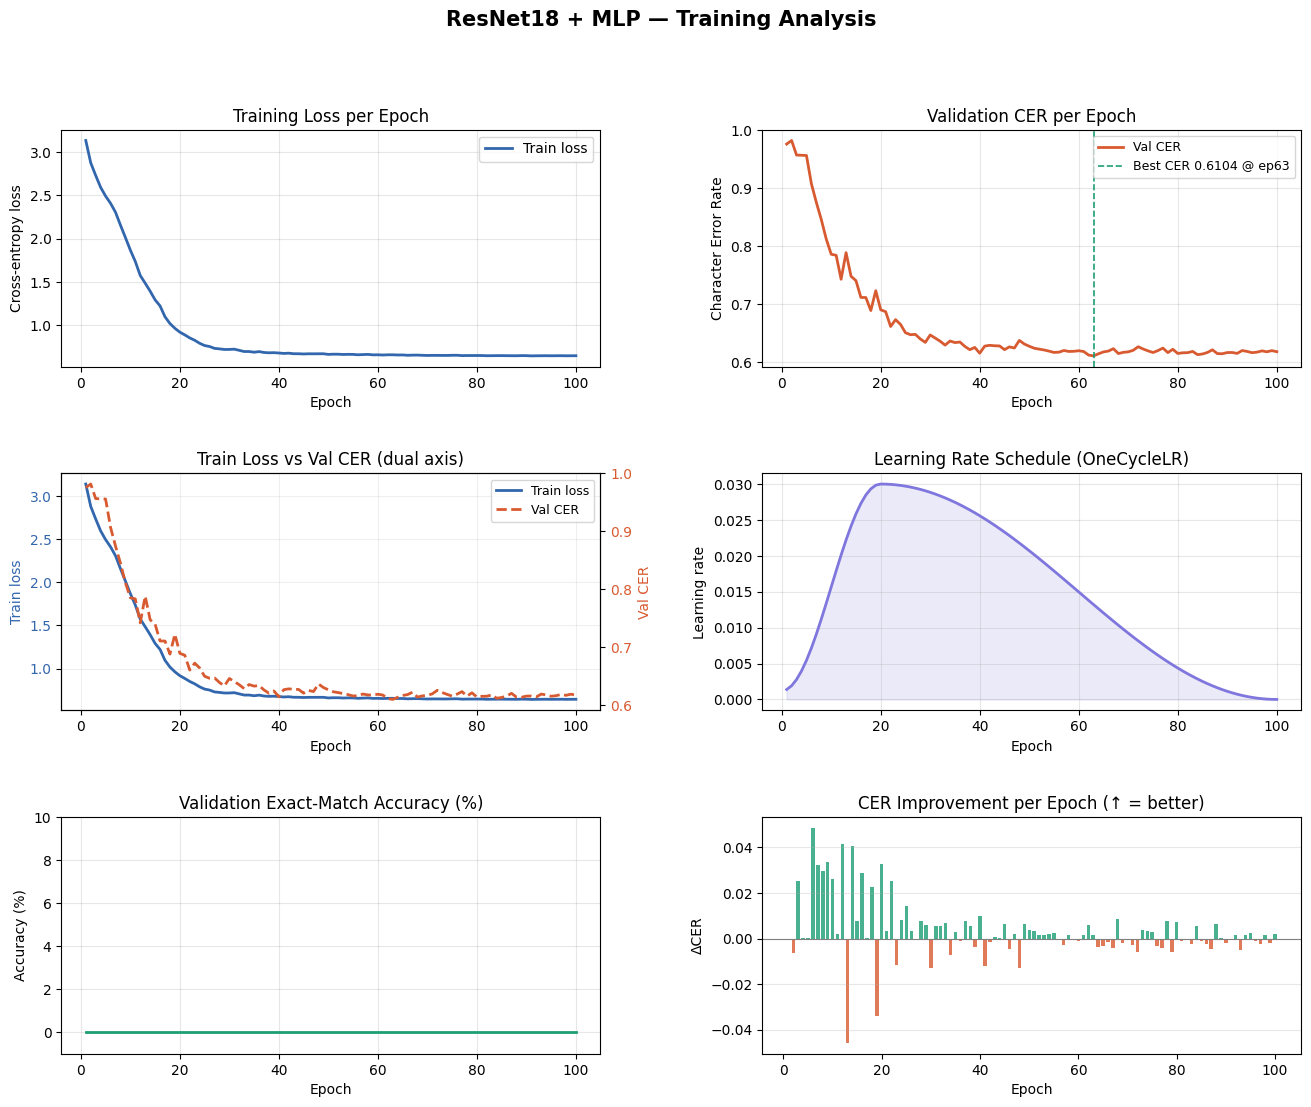


Summary
  Epochs trained   : 100
  Best val CER     : 0.6104  (epoch 63)
  Final train loss : 0.6451
  Final val CER    : 0.6176
  Peak LR          : 0.03000


In [15]:
# ─────────────────────────────────────────
# Training Analysis — plots
# ─────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

epochs_range = list(range(1, len(history['train_loss']) + 1))
train_loss = history['train_loss']
val_cer    = history['val_cer']
val_acc    = history['val_acc']
lr         = history['lr']

best_cer_epoch = int(np.argmin(val_cer)) + 1
best_cer_val   = min(val_cer)

fig = plt.figure(figsize=(16, 12))
fig.suptitle("ResNet18 + MLP — Training Analysis", fontsize=15, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

# ── Plot 1: Training Loss ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs_range, train_loss, color='#3266ad', linewidth=2, label='Train loss')
ax1.set_title("Training Loss per Epoch", fontsize=12)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-entropy loss")
ax1.grid(True, alpha=0.3)
ax1.legend()

# ── Plot 2: Val CER ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs_range, val_cer, color='#D85A30', linewidth=2, label='Val CER')
ax2.axvline(x=best_cer_epoch, color='#1D9E75', linestyle='--', linewidth=1.2,
            label=f'Best CER {best_cer_val:.4f} @ ep{best_cer_epoch}')
ax2.set_title("Validation CER per Epoch", fontsize=12)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Character Error Rate")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# ── Plot 3: Train Loss vs Val CER (dual axis) ──────────────────
ax3 = fig.add_subplot(gs[1, 0])
color_loss = '#3266ad'
color_cer  = '#D85A30'
ax3.plot(epochs_range, train_loss, color=color_loss, linewidth=2, label='Train loss')
ax3.set_ylabel("Train loss", color=color_loss)
ax3.tick_params(axis='y', labelcolor=color_loss)
ax3_r = ax3.twinx()
ax3_r.plot(epochs_range, val_cer, color=color_cer, linewidth=2, linestyle='--', label='Val CER')
ax3_r.set_ylabel("Val CER", color=color_cer)
ax3_r.tick_params(axis='y', labelcolor=color_cer)
ax3.set_title("Train Loss vs Val CER (dual axis)", fontsize=12)
ax3.set_xlabel("Epoch")
ax3.grid(True, alpha=0.2)
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_r.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper right')

# ── Plot 4: Learning Rate Schedule ────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(epochs_range, lr, color='#7F77DD', linewidth=2)
ax4.fill_between(epochs_range, lr, alpha=0.15, color='#7F77DD')
ax4.set_title("Learning Rate Schedule (OneCycleLR)", fontsize=12)
ax4.set_xlabel("Epoch")
ax4.set_ylabel("Learning rate")
ax4.grid(True, alpha=0.3)

# ── Plot 5: Val Accuracy (exact match) ────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(epochs_range, [v * 100 for v in val_acc], color='#1D9E75', linewidth=2)
ax5.set_title("Validation Exact-Match Accuracy (%)", fontsize=12)
ax5.set_xlabel("Epoch")
ax5.set_ylabel("Accuracy (%)")
ax5.set_ylim(-1, max(max(val_acc)*100 + 5, 10))
ax5.grid(True, alpha=0.3)

# ── Plot 6: CER improvement rate (delta) ──────────────────────
ax6 = fig.add_subplot(gs[2, 1])
cer_delta = [0] + [val_cer[i-1] - val_cer[i] for i in range(1, len(val_cer))]
colors_delta = ['#1D9E75' if d >= 0 else '#D85A30' for d in cer_delta]
ax6.bar(epochs_range, cer_delta, color=colors_delta, alpha=0.8, width=0.7)
ax6.axhline(0, color='gray', linewidth=0.8)
ax6.set_title("CER Improvement per Epoch (↑ = better)", fontsize=12)
ax6.set_xlabel("Epoch")
ax6.set_ylabel("ΔCER")
ax6.grid(True, alpha=0.3, axis='y')

plt.savefig(out_dir / "training_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSummary")
print(f"  Epochs trained   : {len(train_loss)}")
print(f"  Best val CER     : {best_cer_val:.4f}  (epoch {best_cer_epoch})")
print(f"  Final train loss : {train_loss[-1]:.4f}")
print(f"  Final val CER    : {val_cer[-1]:.4f}")
print(f"  Peak LR          : {max(lr):.5f}")
